In [ ]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_validate,
    GridSearchCV
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, f1_score, precision_score, recall_score
)
from sklearn.inspection import permutation_importance

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from imblearn.over_sampling import SMOTE
from sklearn.compose import ColumnTransformer
RANDOM_STATE = 42
sns.set_style("whitegrid")
pd.set_option("future.infer_string", False)

In [ ]:
DATA_PATH = "/content/Sleep_Quality_202 (2).csv"

df = pd.read_csv(DATA_PATH)

print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
df.head()

Rows: 202, Columns: 11


,Timestamp,1. Age,2. Gender,"3. On average, how many hours do you sleep per night?",4. How many hours of screen time do you have before bed?,"5. How many cups of caffeinated drinks (coffee, tea, energy drinks) do you have per day?",6. How many hours before bed time do you usually have your last caffeinated drink?,"7. On average, how much time of physical exercise do you get per day?","8. On a scale of 1–5, how would you rate your daily stress level?",9. When do you usually sleep?,"10. On a scale of 1–5, how would you rate your overall sleep quality?"
0,29/07/2026 20:35:14,24,Male,3–5 hours,1–2 hours,1,6+ hours before bed,30-60 Minutes,2,Morning,3
1,29/07/2026 20:38:40,23,Male,9–11+ hours,1–2 hours,1,6+ hours before bed,30-60 Minutes,3,Morning,4
2,29/07/2026 20:39:11,25,Female,0–2 hours,1–2 hours,1,0–2 hours before bed,30-60 Minutes,2,Night,2
3,29/07/2026 20:40:26,24,Male,3–5 hours,3+ hours,2,6+ hours before bed,2+,5,Morning,1
4,29/07/2026 20:43:09,28,Male,6–8 hours,0–1 hours,1,6+ hours before bed,30-60 Minutes,1,Night,4


Clean and rename

In [ ]:
COLUMN_RENAME_MAP = {
    "1. Age": "Age",
    "2. Gender": "Gender",
    "3. On average, how many hours do you sleep per night?": "Sleep Duration",
    "4. How many hours of screen time do you have before bed?": "Screen Time Before Bed",
    "5. How many cups of caffeinated drinks (coffee, tea, energy drinks) do you have per day?": "Caffeine Cups",
    "6. How many hours before bed time do you usually have your last caffeinated drink?": "Caffeine Timing",
    "7. On average, how much time of physical exercise do you get per day?": "Exercise",
    "8. On a scale of 1–5, how would you rate your daily stress level?": "Stress Level",
    "9. When do you usually sleep?": "Sleep Time",
    "10. On a scale of 1–5, how would you rate your overall sleep quality?": "Sleep Quality Score",
}

df = df.drop(columns=["Timestamp"], errors="ignore")
df = df.rename(columns=COLUMN_RENAME_MAP)

# Remove duplicate responses
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Removed {before - len(df)} duplicate row(s).")

# drop anything under 10
before = len(df)
df = df[df["Age"] >= 10].reset_index(drop=True)
print(f"Removed {before - len(df)} row(s) with an invalid age.")

#  "no reported exercise"
df["Exercise"] = df["Exercise"].fillna("No Exercise")

df

Removed 0 duplicate row(s).
Removed 0 row(s) with an invalid age.


,Age,Gender,Sleep Duration,Screen Time Before Bed,Caffeine Cups,Caffeine Timing,Exercise,Stress Level,Sleep Time,Sleep Quality Score
0,24,Male,3–5 hours,1–2 hours,1,6+ hours before bed,30-60 Minutes,2,Morning,3
1,23,Male,9–11+ hours,1–2 hours,1,6+ hours before bed,30-60 Minutes,3,Morning,4
2,25,Female,0–2 hours,1–2 hours,1,0–2 hours before bed,30-60 Minutes,2,Night,2
3,24,Male,3–5 hours,3+ hours,2,6+ hours before bed,2+,5,Morning,1
4,28,Male,6–8 hours,0–1 hours,1,6+ hours before bed,30-60 Minutes,1,Night,4
...,...,...,...,...,...,...,...,...,...,...
197,24,Female,9–11+ hours,2–3 hours,0,Never,No Exercise,1,Morning,4
198,29,Male,6–8 hours,1–2 hours,1,3–5 hours before bed,1-2 Hours,2,Night,4
199,37,Male,6–8 hours,2–3 hours,2,0–2 hours before bed,30-60 Minutes,2,Morning,2
200,40,Male,6–8 hours,1–2 hours,2,3–5 hours before bed,Under 30 Minutes,2,Night,3


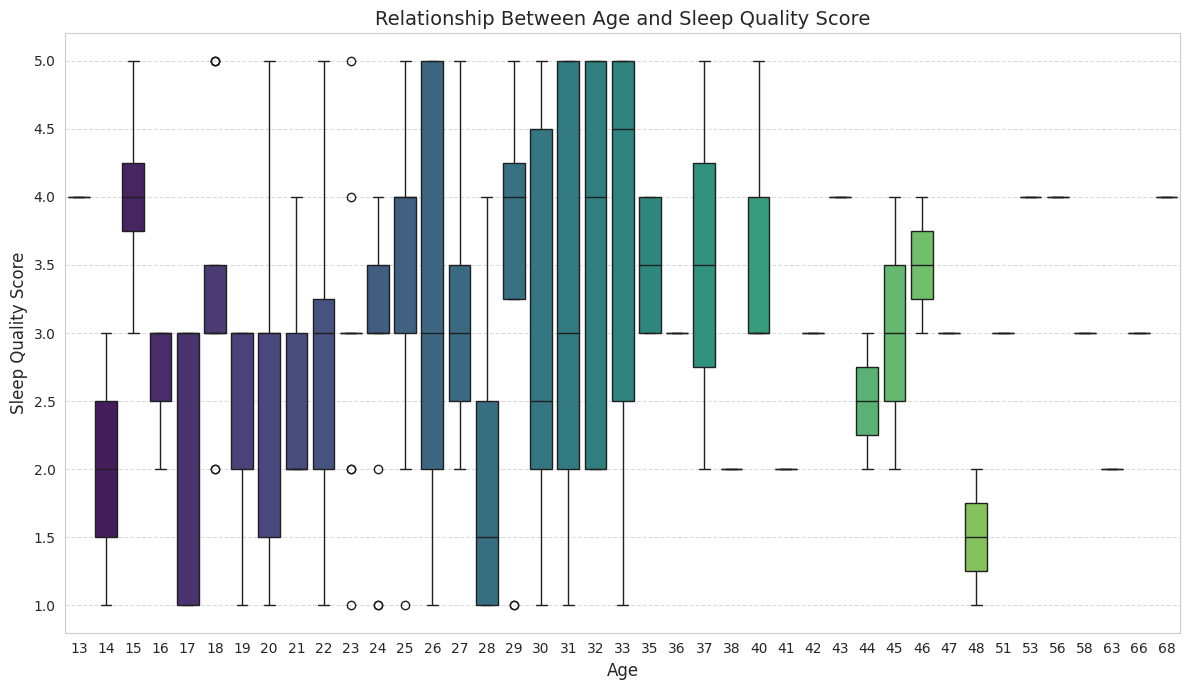

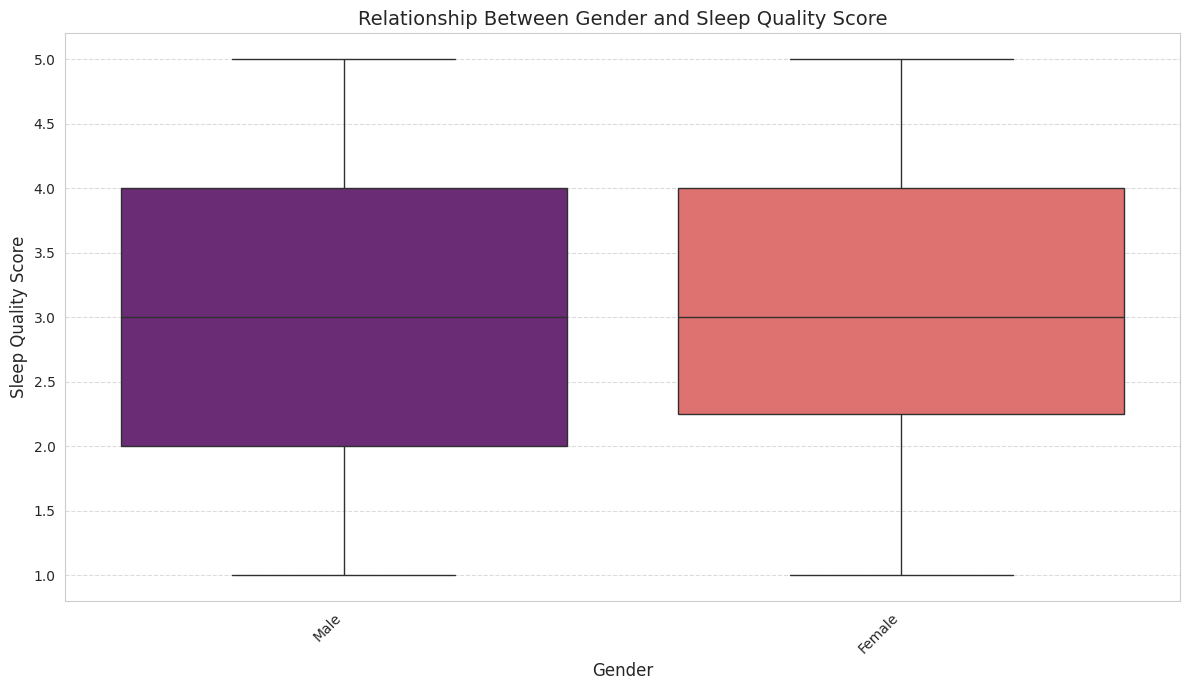

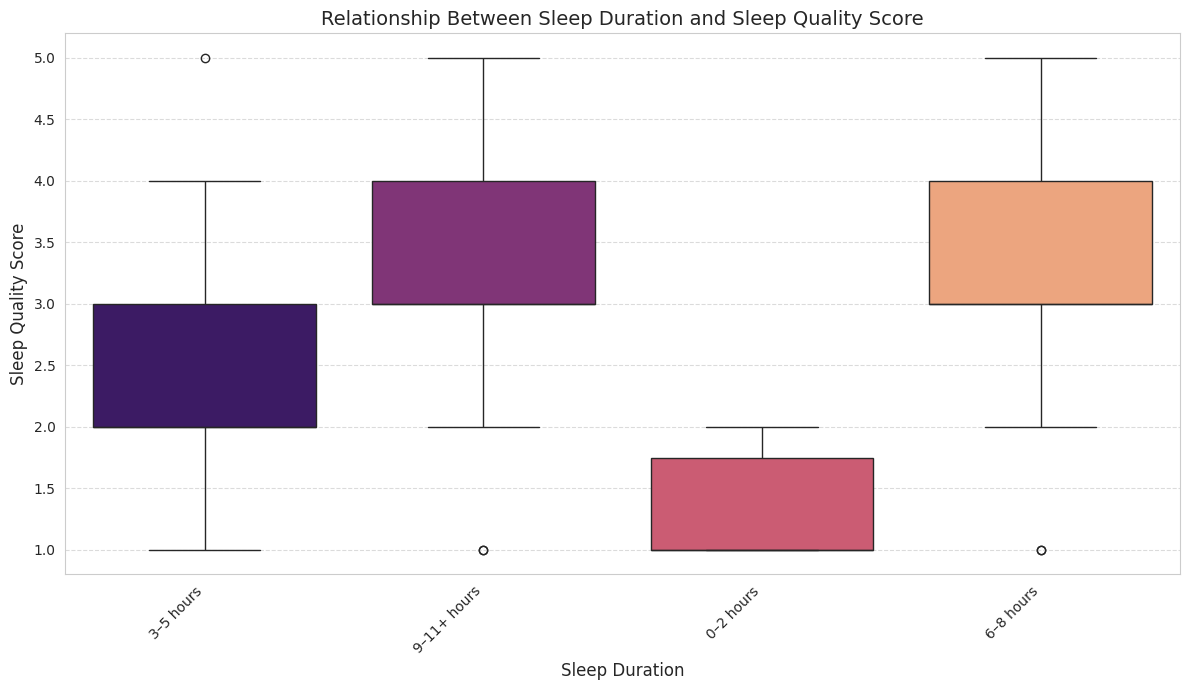

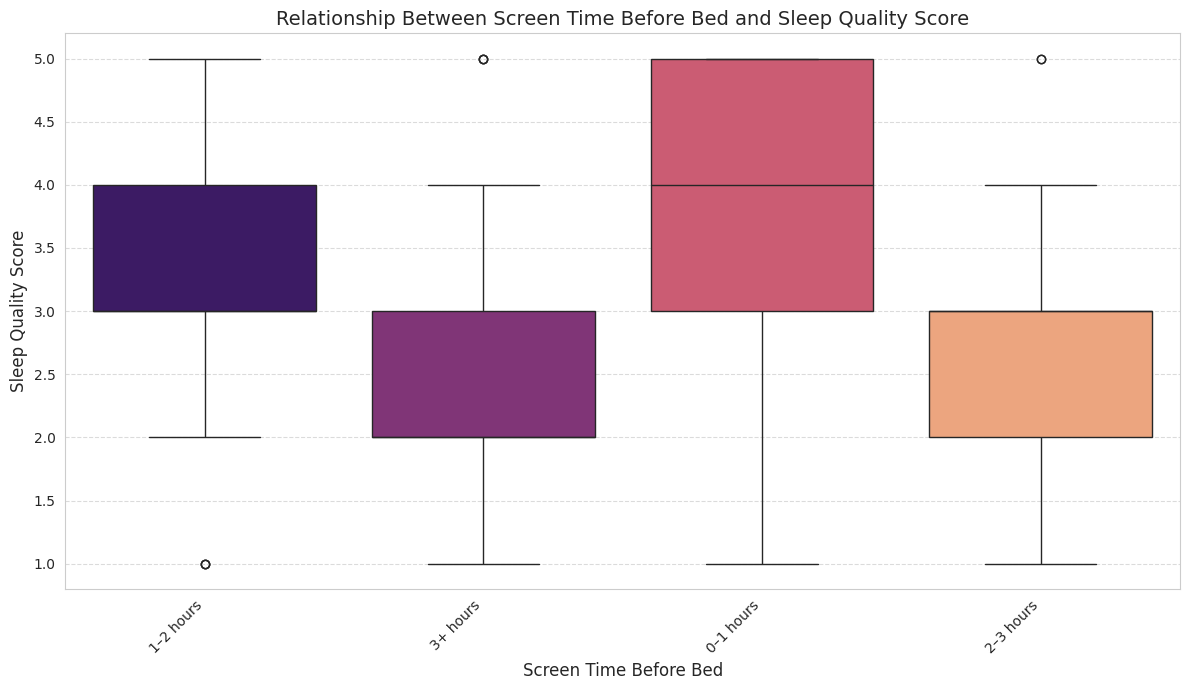

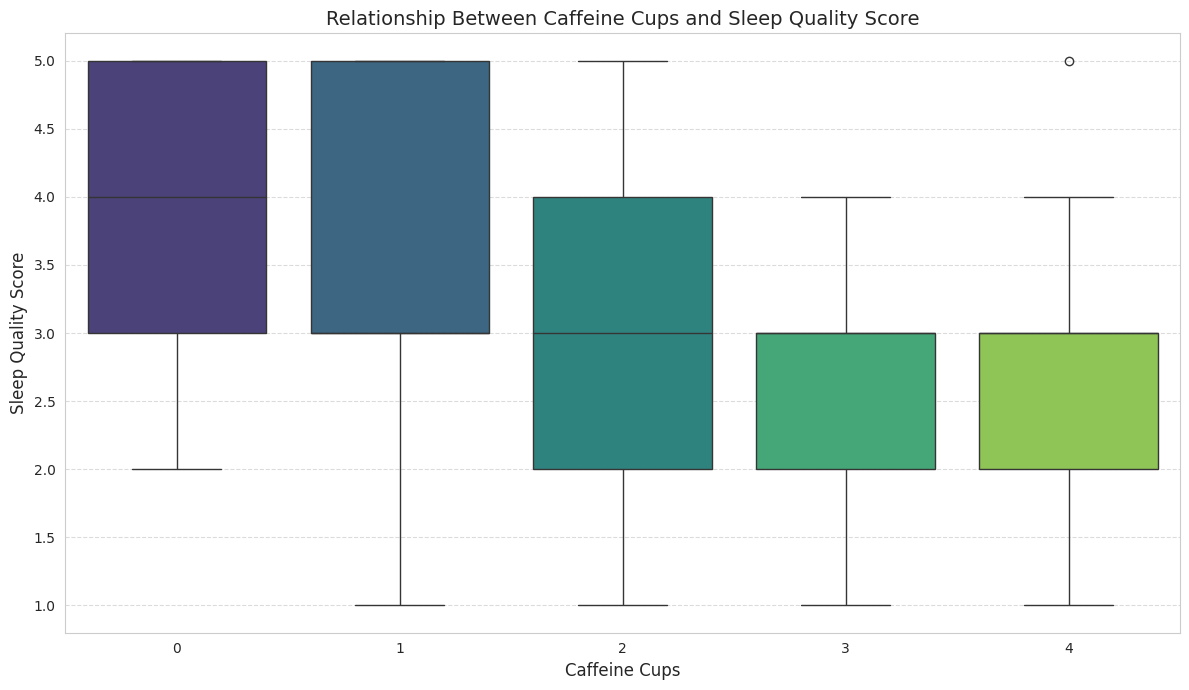

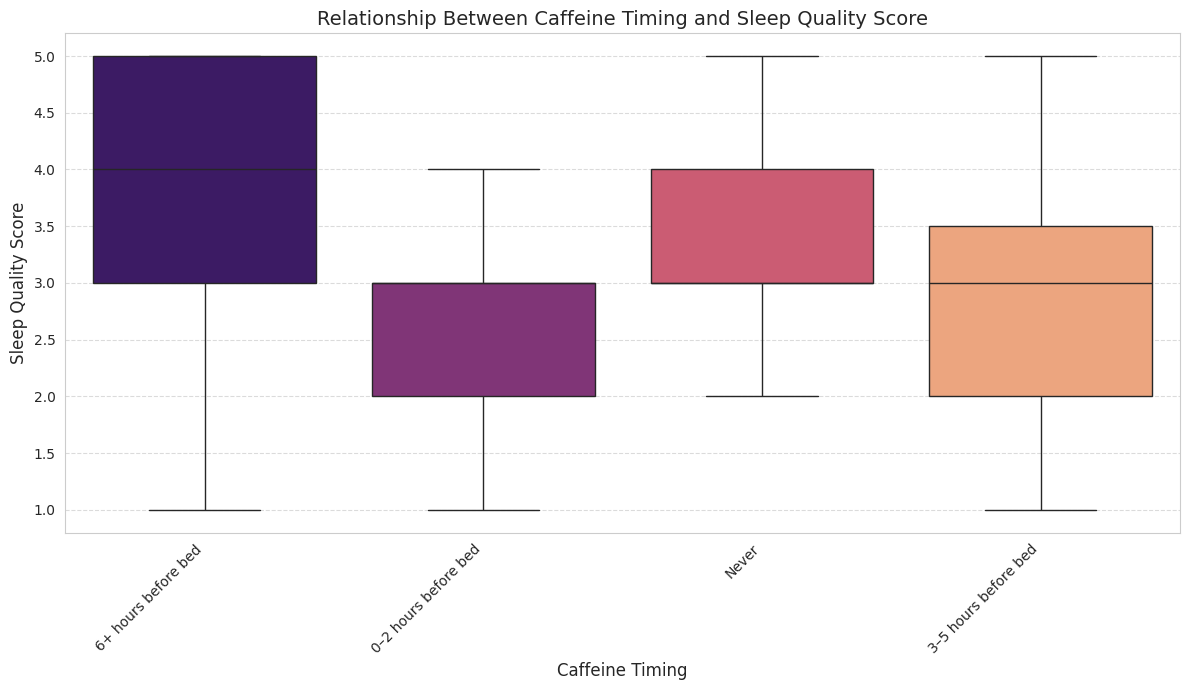

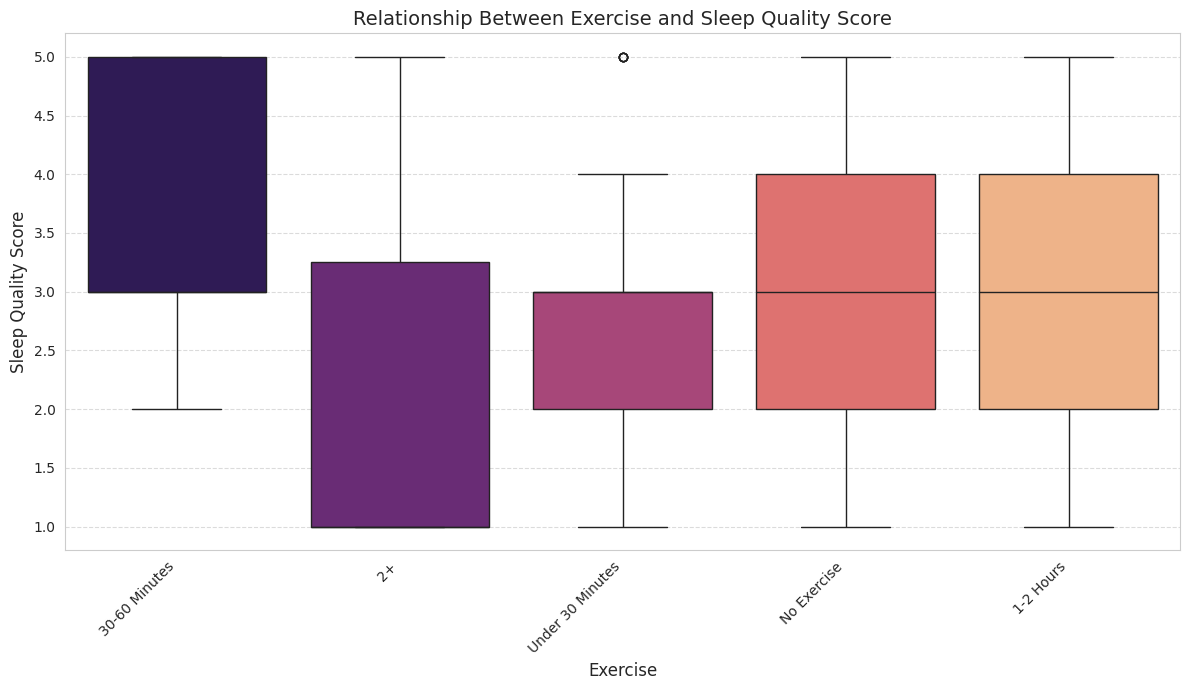

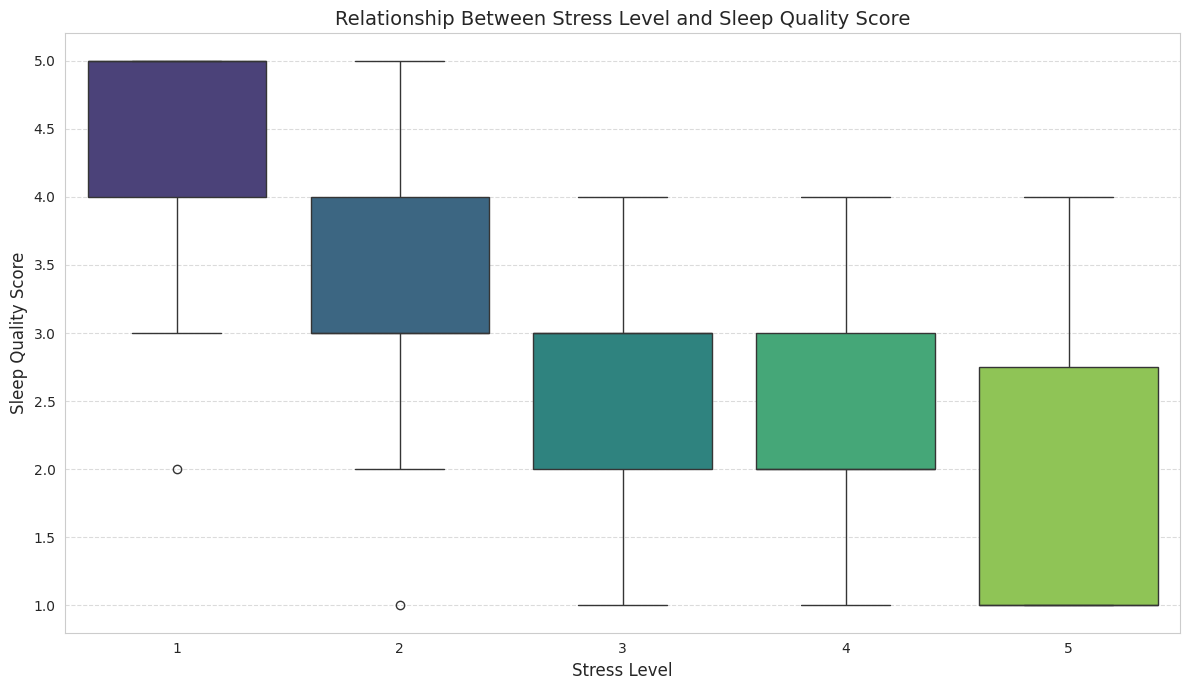

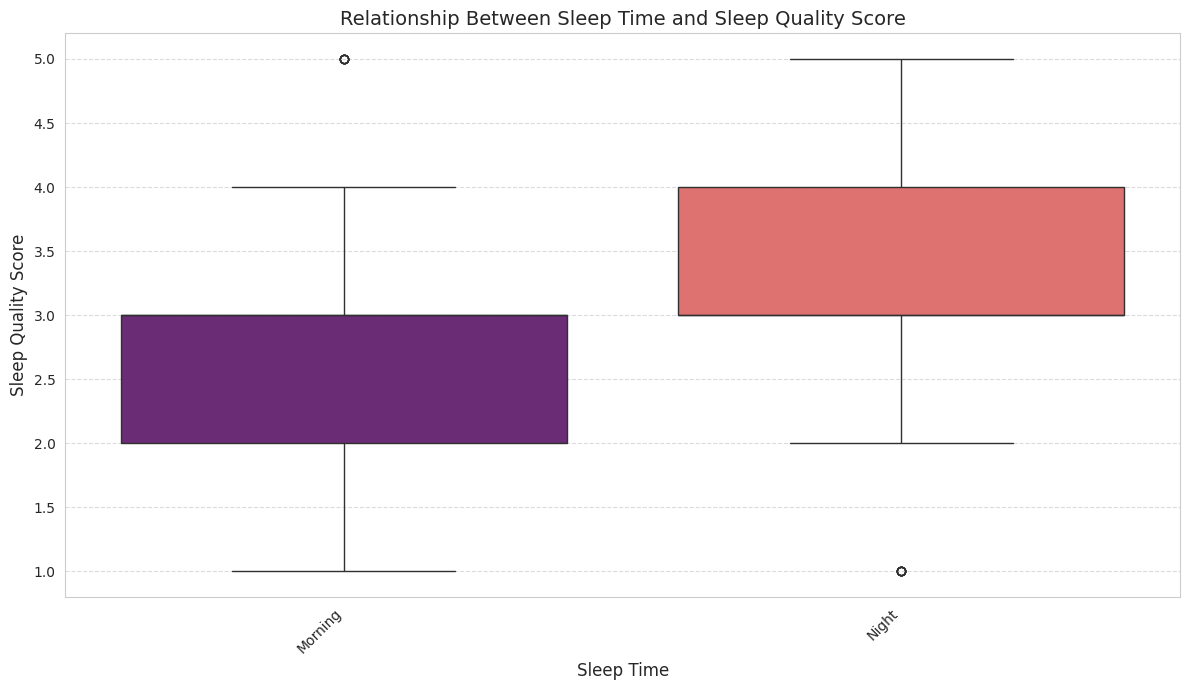

In [ ]:
for column in df.columns:
    if column == 'Sleep Quality Score':
        continue

    plt.figure(figsize=(12, 7))
    if df[column].dtype in ['int64', 'float64']: # For numerical columns, plot their distribution across Sleep Quality Score levels
        sns.boxplot(x=column, y='Sleep Quality Score', data=df, palette='viridis')
        plt.title(f'Relationship Between {column} and Sleep Quality Score', fontsize=14)
        plt.xlabel(column, fontsize=12)
        plt.ylabel('Sleep Quality Score', fontsize=12)
    else: # For categorical columns, plot Sleep Quality Score distribution for each category
        sns.boxplot(x=column, y='Sleep Quality Score', data=df, palette='magma')
        plt.title(f'Relationship Between {column} and Sleep Quality Score', fontsize=14)
        plt.xlabel(column, fontsize=12)
        plt.ylabel('Sleep Quality Score', fontsize=12)
        plt.xticks(rotation=45, ha='right', fontsize=10)

    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

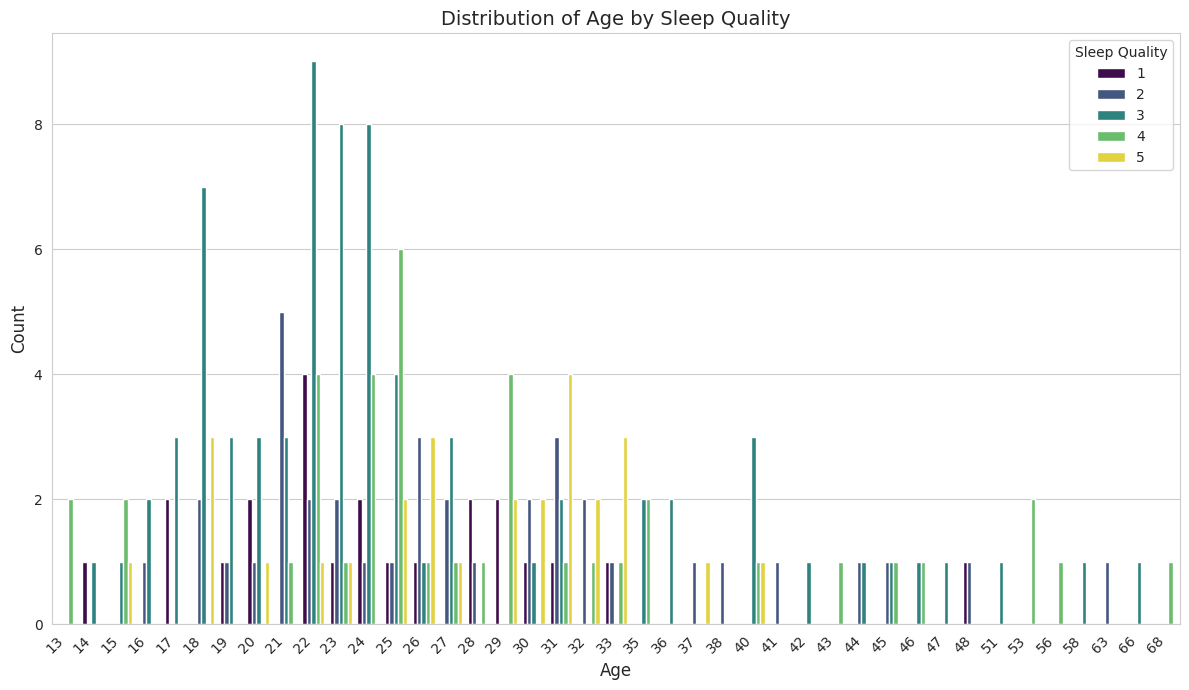

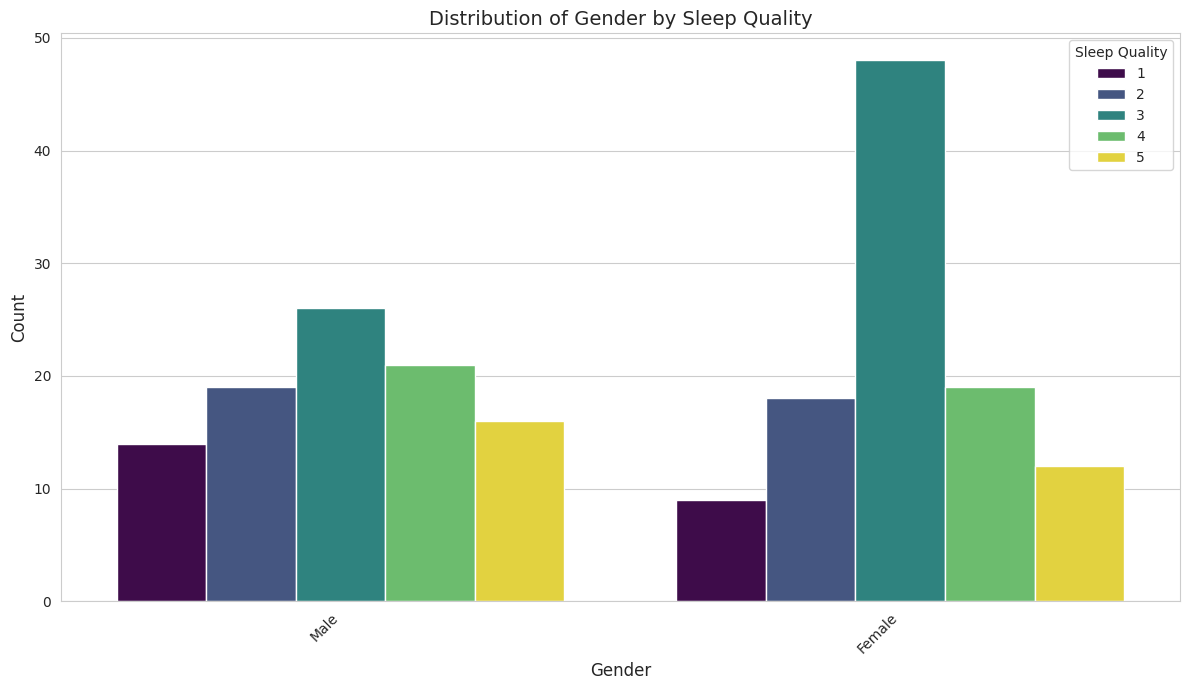

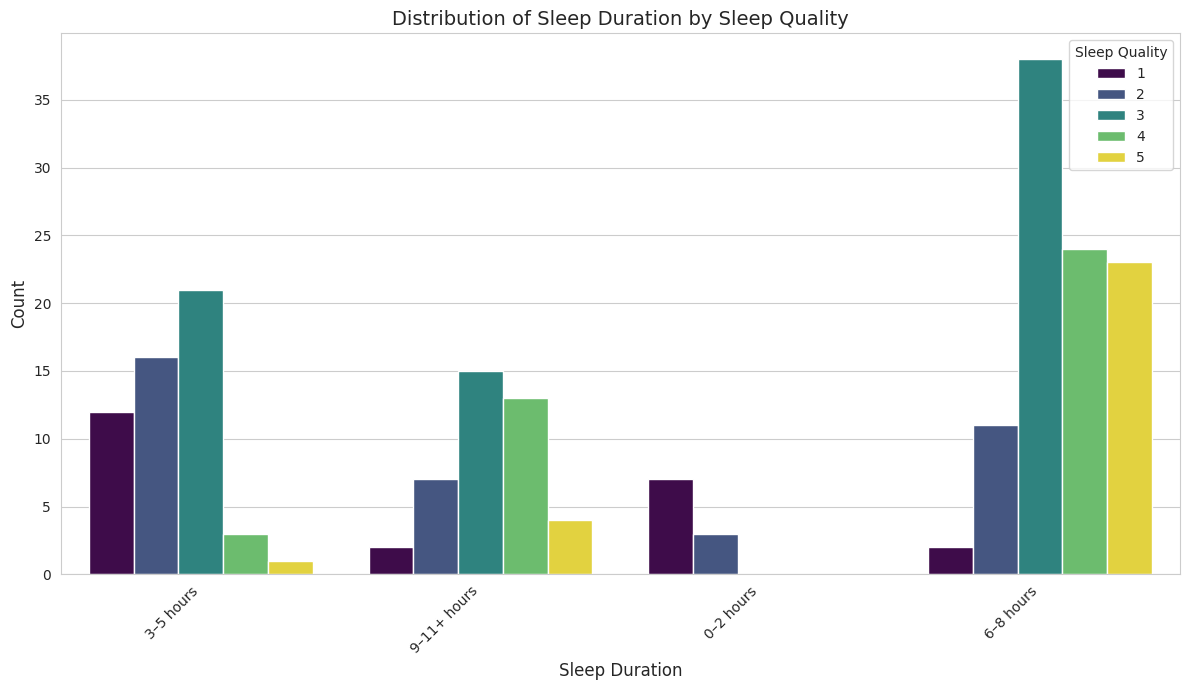

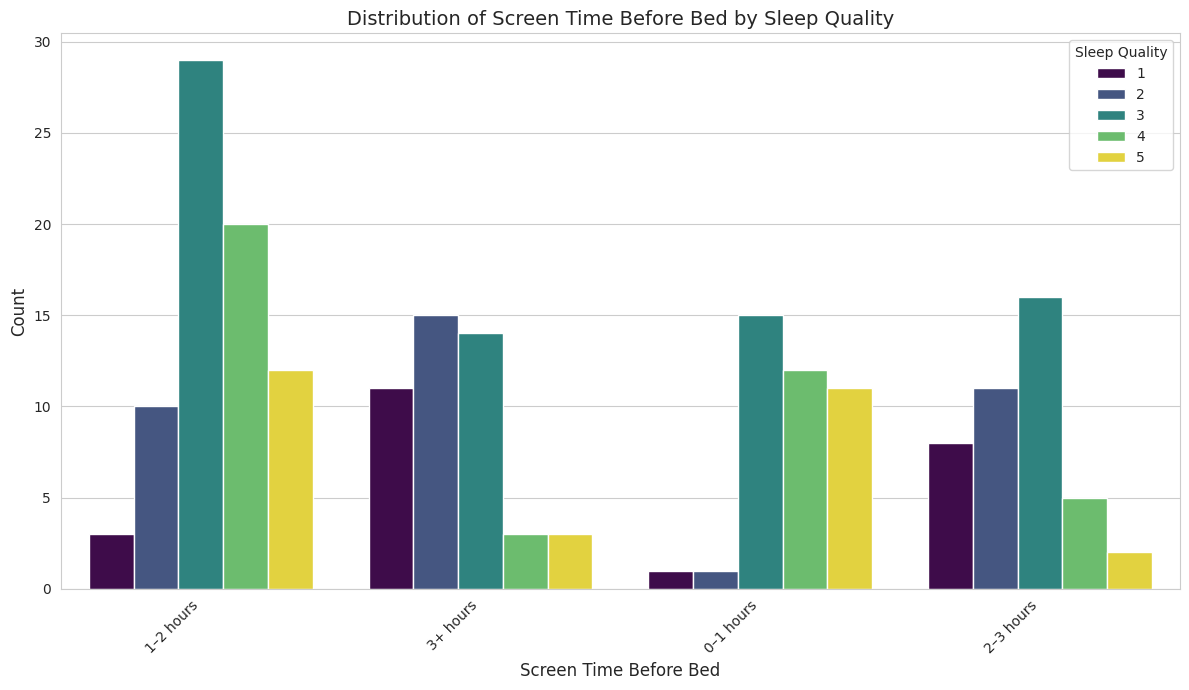

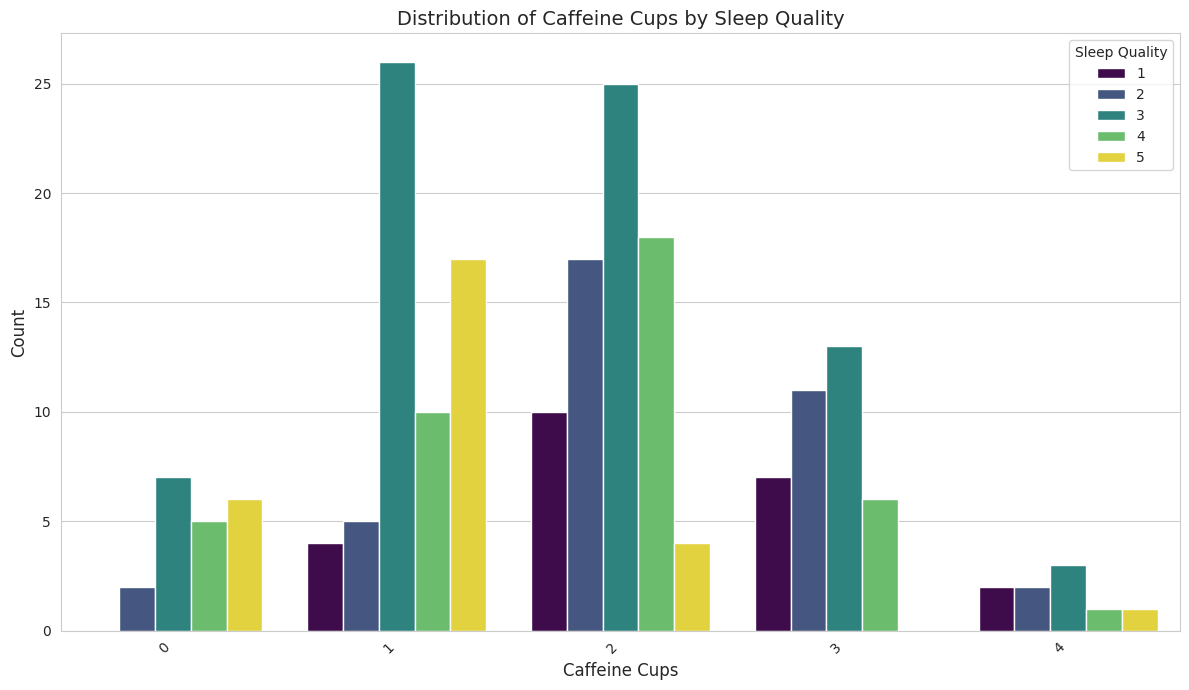

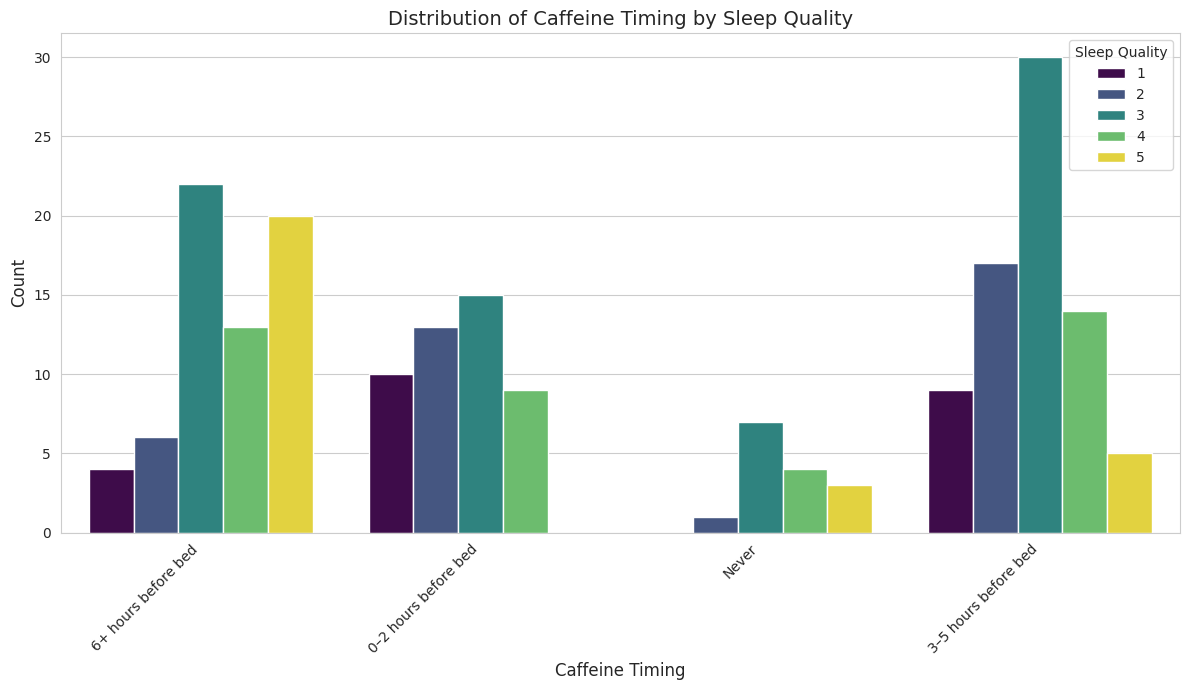

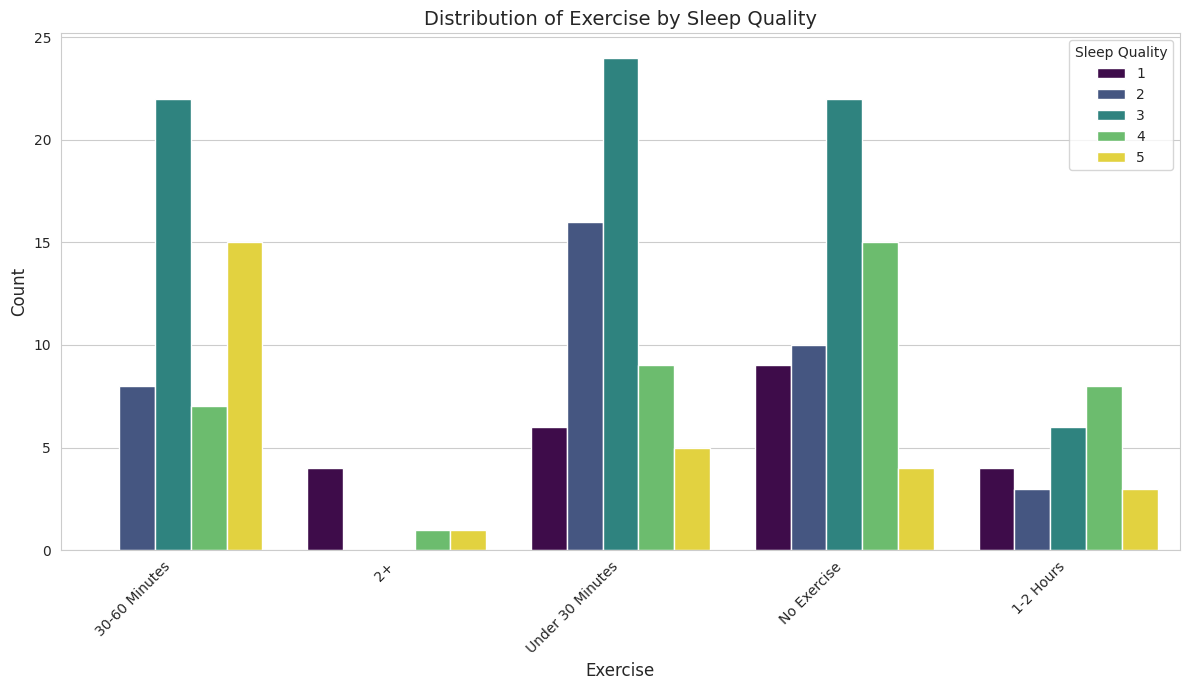

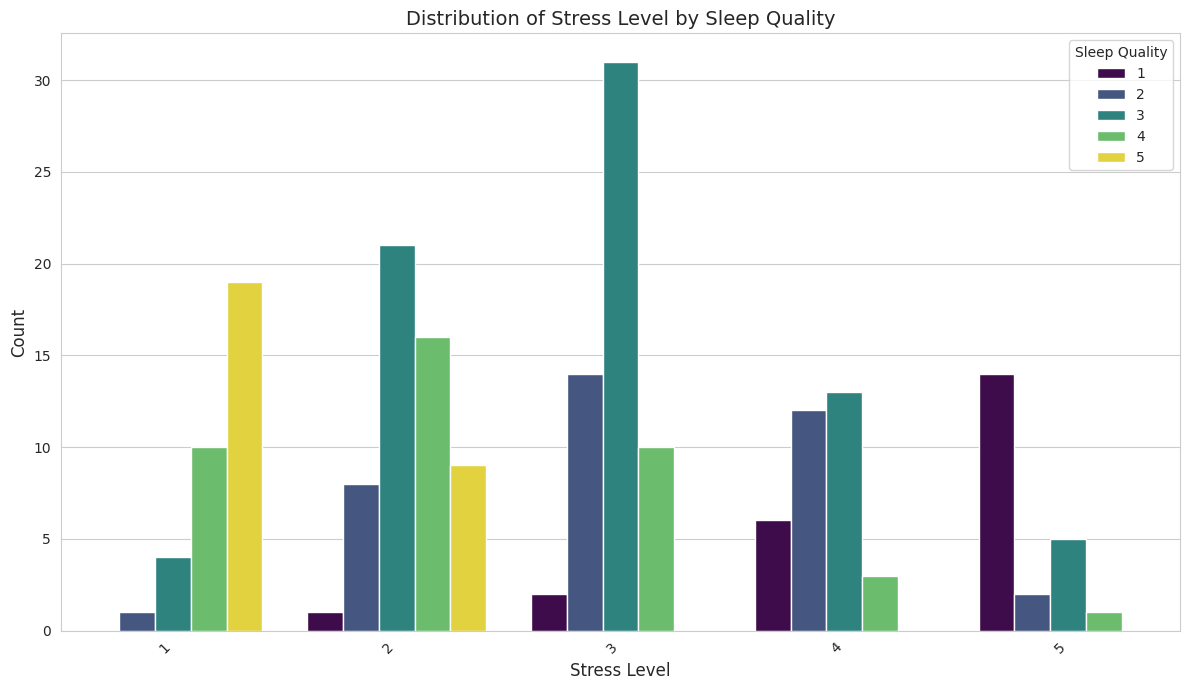

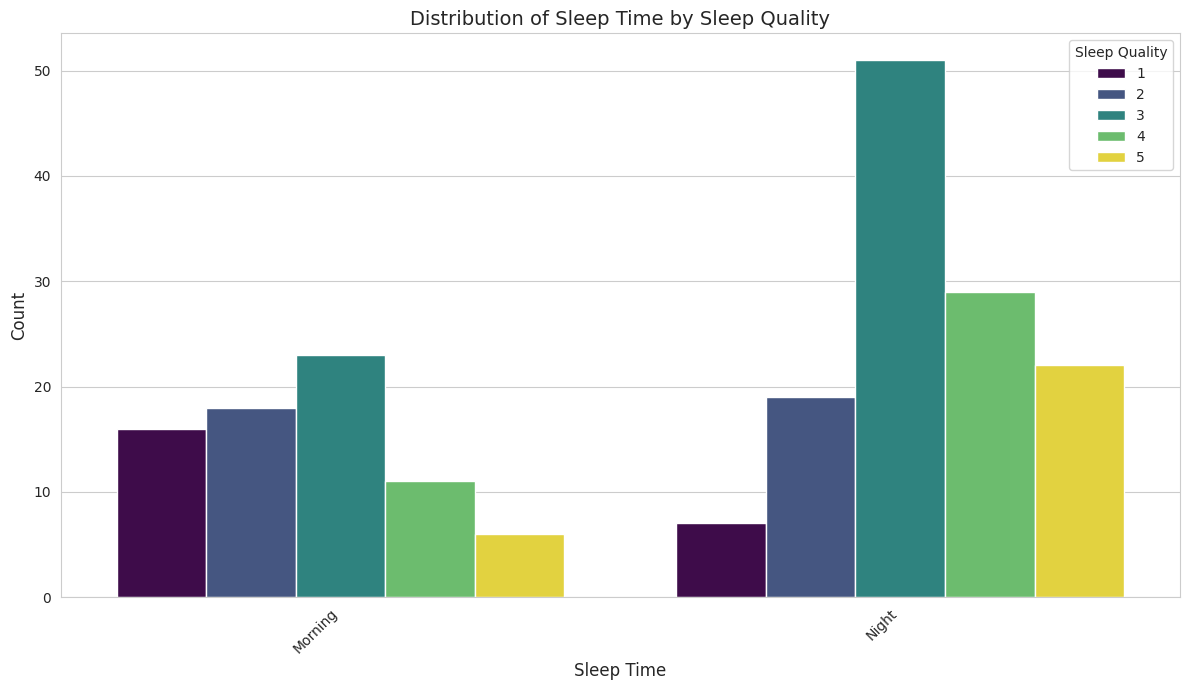

In [ ]:
for column in df.columns:
    if column == 'Sleep Quality Score':
        continue

    plt.figure(figsize=(12, 7))
    sns.countplot(x=column, hue='Sleep Quality Score', data=df, palette='viridis') # Changed from 'Sleep_Quality'
    plt.title(f'Distribution of {column} by Sleep Quality', fontsize=14)
    plt.xlabel(column, fontsize=12)
    plt.ylabel('Count', fontsize=12)
    plt.xticks(rotation=45, ha='right', fontsize=10)
    plt.legend(title='Sleep Quality')
    plt.tight_layout()
    plt.show()

##Feature Engineering

| Score | Class |
|---|---|
| 1–2 |  Poor |
| 3 |  Fair |
| 4–5 |  Good |

In [ ]:
SLEEP_DURATION_MAP = {
    "0–2 hours": 1,
    "3–5 hours": 2,
    "6–8 hours": 3,
    "9–11+ hours": 4,
}
df["Sleep_Duration_Hours"] = df["Sleep Duration"].map(SLEEP_DURATION_MAP)

# Turning the 1-5 sleep quality score into Poor / Fair / Good
def classify_sleep_quality(score):
    if score <= 2:
        return "Poor"
    elif score == 3:
        return "Fair"
    else:
        return "Good"

df["Sleep Quality"] = df["Sleep Quality Score"].apply(classify_sleep_quality)

df["Sleep Quality"].value_counts().reindex(["Poor", "Fair", "Good"])

,count
Sleep Quality,
Poor,60
Fair,74
Good,68


## 4. Explore the Data

A quick look at the target and a few relationships before we model anything.

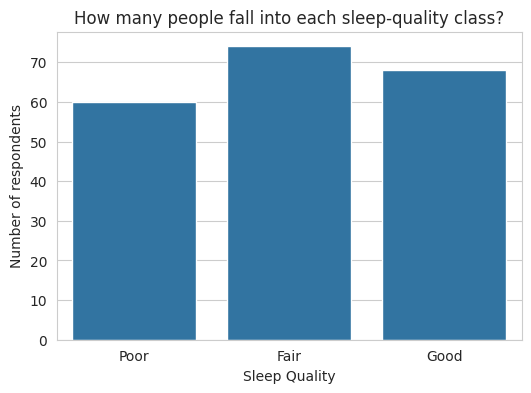

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Sleep Quality", order=["Poor", "Fair", "Good"])
plt.title("How many people fall into each sleep-quality class?")
plt.ylabel("Number of respondents")
plt.show()

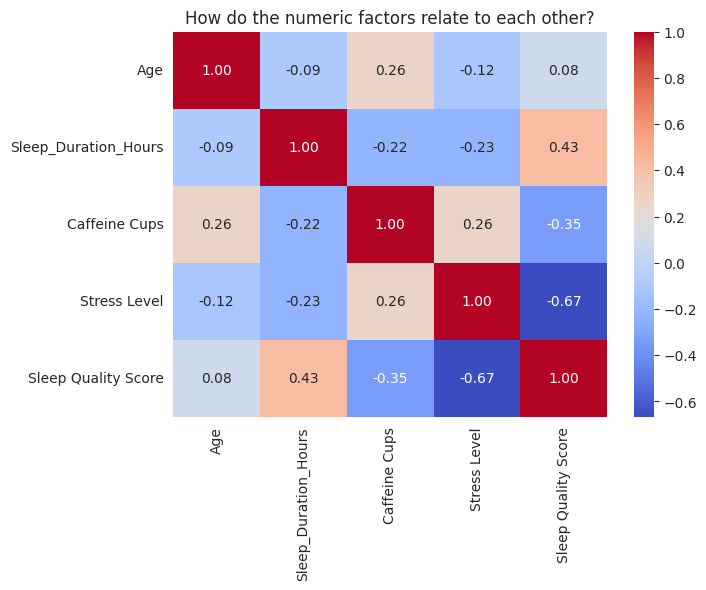

In [ ]:
numeric_cols = ["Age", "Sleep_Duration_Hours", "Caffeine Cups", "Stress Level", "Sleep Quality Score"]

plt.figure(figsize=(7, 5))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("How do the numeric factors relate to each other?")
plt.show()

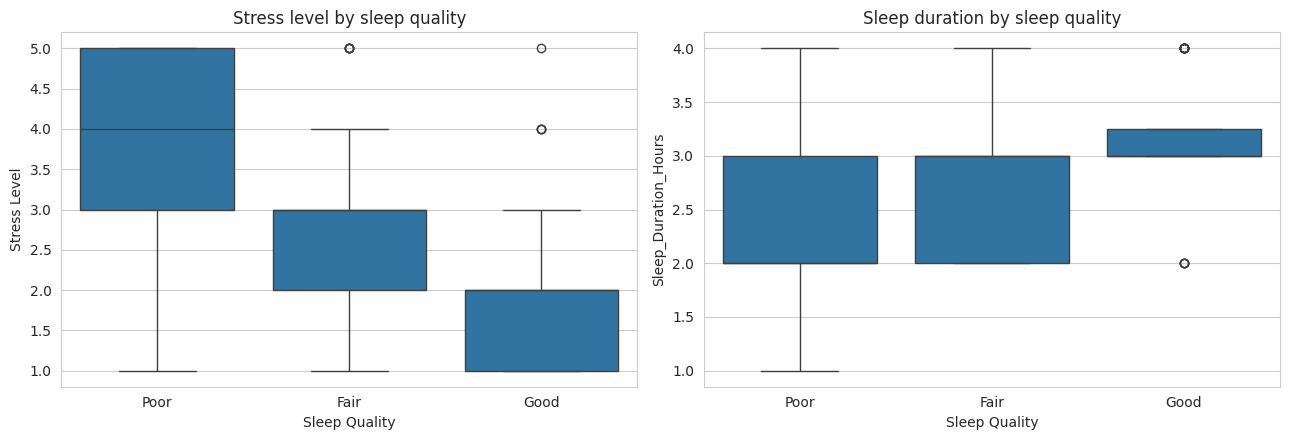

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.boxplot(data=df, x="Sleep Quality", y="Stress Level",
            order=["Poor", "Fair", "Good"], ax=axes[0])
axes[0].set_title("Stress level by sleep quality")

sns.boxplot(data=df, x="Sleep Quality", y="Sleep_Duration_Hours",
            order=["Poor", "Fair", "Good"], ax=axes[1])
axes[1].set_title("Sleep duration by sleep quality")

plt.tight_layout()
plt.show()

people with Good sleep quality tend to report lower stress and longer sleep duration than people with Poor sleep quality

##Modeling


- Numeric (Age, Sleep Duration, Caffeine Cups, Stress Level) -> fill any missing values with the median, then scale
- Nominal categories with no order (Gender, Sleep Time) -> fill missing with the most common value, then one-hot encode
- Ordered categories (Screen Time, Caffeine Timing, Exercise) -> fill missing with the most common value, then ordinal-encode using their natural order

In [ ]:
FEATURES = [
    "Age", "Gender", "Sleep_Duration_Hours", "Sleep Time",
    "Screen Time Before Bed", "Caffeine Cups", "Caffeine Timing",
    "Exercise", "Stress Level",
]
TARGET = "Sleep Quality"

X = df[FEATURES].copy()
y = df[TARGET].copy()

numeric_features = ["Age", "Sleep_Duration_Hours", "Caffeine Cups", "Stress Level"]
nominal_features = ["Gender", "Sleep Time"]
ordinal_features = ["Screen Time Before Bed", "Caffeine Timing", "Exercise"]

# The natural, human order for each ordered category
ordinal_categories = [
    ["0–1 hours", "1–2 hours", "2–3 hours", "3+ hours"],                          # Screen Time Before Bed
    ["Never", "6+ hours before bed", "3–5 hours before bed", "0–2 hours before bed"],  # Caffeine Timing
    ["No Exercise", "Under 30 Minutes", "30-60 Minutes", "1-2 Hours", "2+"],       # Exercise
]

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

nominal_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

ordinal_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ordinal", OrdinalEncoder(categories=ordinal_categories, handle_unknown="use_encoded_value", unknown_value=-1)),
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_transformer, numeric_features),
    ("nominal", nominal_transformer, nominal_features),
    ("ordinal", ordinal_transformer, ordinal_features),
])

print("Preprocessing pipeline. Features:")
for f in FEATURES:
    print(" -", f)

Preprocessing pipeline. Features:
 - Age
 - Gender
 - Sleep_Duration_Hours
 - Sleep Time
 - Screen Time Before Bed
 - Caffeine Cups
 - Caffeine Timing
 - Exercise
 - Stress Level


##Train / Test Split
 20% of the data as a test set

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (161, 9)
Test set: (41, 9)


In [ ]:
X_train_processed = preprocessor.fit_transform(X_train)

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train_processed, y_train
)

print(f"Training data size before SMOTE: {X_train.shape[0]}")
print(f"Training data size after SMOTE: {X_train_resampled.shape[0]}")

Training data size before SMOTE: 161
Training data size after SMOTE: 177


## Compare  Models

we try six common classifiers and compare them using 5-fold stratified cross-validation on the training set. Each model is scored on:

- Accuracy
- Macro Precision / Recall
- Macro F1 <- this is the main selection metric

useing macro F1 because it treats Poor, Fair, and Good as equally important, even if one class has fewer examples which matters here because "Fair" is  the smallest group

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True, class_weight="balanced", random_state=RANDOM_STATE),
    "Decision Tree": DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, class_weight="balanced"),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {"accuracy": "accuracy", "precision_macro": "precision_macro",
           "recall_macro": "recall_macro", "f1_macro": "f1_macro"}

results = []
pipelines = {}

for name, model in models.items():
    pipe = Pipeline([("preprocessor", preprocessor), ("model", model)])
    pipelines[name] = pipe

    scores = cross_validate(pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)

    results.append({
        "Model": name,
        "CV Accuracy": scores["test_accuracy"].mean(),
        "CV Precision": scores["test_precision_macro"].mean(),
        "CV Recall": scores["test_recall_macro"].mean(),
        "CV Macro F1": scores["test_f1_macro"].mean(),
        "F1 Std": scores["test_f1_macro"].std(),
    })

results_df = pd.DataFrame(results).sort_values("CV Macro F1", ascending=False).reset_index(drop=True)
results_df

,Model,CV Accuracy,CV Precision,CV Recall,CV Macro F1,F1 Std
0,SVM,0.634280,0.669666,0.640101,0.634968,0.078899
1,Gradient Boosting,0.621591,0.626852,0.627306,0.623741,0.064937
2,Logistic Regression,0.615152,0.639249,0.621145,0.617831,0.051185
3,Random Forest,0.590341,0.634358,0.591549,0.591815,0.076253
4,KNN,0.571591,0.626712,0.568350,0.572405,0.040828
5,Decision Tree,0.558902,0.578134,0.566162,0.560551,0.062699


In [ ]:
# The mixed-type preprocessing pipeline defined above is intentionally kept.
# Do not overwrite it with a passthrough-only preprocessor, because the final
# deployment pipeline must preserve One-Hot Encoding and Ordinal Encoding.
print("Using the mixed-type preprocessing pipeline defined in the modeling section.")

In [ ]:
best_model_name = results_df.iloc[0]["Model"]
print(f"Best model: {best_model_name}")

best_pipeline = pipelines[best_model_name]
best_pipeline.fit(X_train, y_train)

test_accuracy = best_pipeline.score(X_test, y_test)
print(f"Best model accuracy on Test Set: {test_accuracy*100:.2f}%")

Best model: SVM
Best model accuracy on Test Set: 65.85%


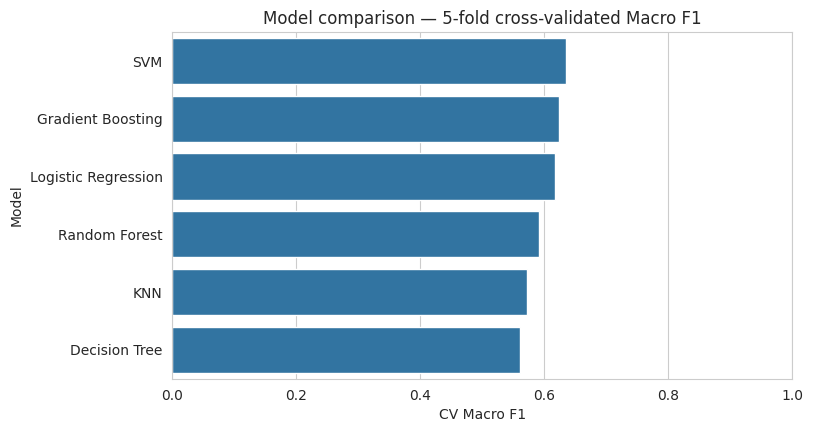

In [ ]:
plt.figure(figsize=(8, 4.5))
sns.barplot(data=results_df, x="CV Macro F1", y="Model")
plt.title("Model comparison — 5-fold cross-validated Macro F1")
plt.xlim(0, 1)
plt.show()

## Best Model


In [ ]:
best_model_name = results_df.iloc[0]["Model"]
best_cv_f1 = results_df.iloc[0]["CV Macro F1"]

print(f"Best model: {best_model_name}  (CV Macro F1 = {best_cv_f1:.3f})")

best_pipeline = pipelines[best_model_name]
best_pipeline.fit(X_train, y_train)

Best model: SVM  (CV Macro F1 = 0.635)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age',
                                                   'Sleep_Duration_Hours',
                                                   'Caffeine Cups',
                                                   'Stress Level']),
                                                 ('nominal',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='igno...
                                                                                               'hours'],
                                                                                              ['Never',
                                                                                               '6+ '
                                                                                               'hours '
                                                                                               'before '
                                                                                               'bed',
                                                                                               '3–5 '
                                                                                               'hours '
                                                                                               'before '
                                                                                               'bed',
                                                                                               '0–2 '
                                                                                               'hours '
                                                                                               'before '
                                                                                               'bed'],
                                                                                              ['No '
                                                                                               'Exercise',
                                                                                               'Under '
                                                                                               '30 '
                                                                                               'Minutes',
                                                                                               '30-60 '
                                                                                               'Minutes',
                                                                                               '1-2 '
                                                                                               'Hours',
                                                                                               '2+']],
                                                                                  handle_unknown='use_encoded_value',
                                                                                  unknown_value=-1))]),
                                                  ['Screen Time Before Bed',
                                                   'Caffeine Timing',
      

##Fine tune the best model (if it's Random Forest)

For any other winning model, we keep it as-is

In [ ]:
if best_model_name == "Random Forest":
    param_grid = {
        "model__n_estimators": [100, 300, 500],
        "model__max_depth": [None, 3, 5, 10],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4],
    }

    tuning_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(random_state=RANDOM_STATE, class_weight="balanced")),
    ])

    grid_search = GridSearchCV(tuning_pipeline, param_grid, scoring="f1_macro", cv=cv, n_jobs=-1)
    grid_search.fit(X_train, y_train)

    final_pipeline = grid_search.best_estimator_
    print("Best parameters found:", grid_search.best_params_)
    print(f"Tuned CV Macro F1: {grid_search.best_score_:.3f}")
else:
    final_pipeline = best_pipeline
    print(f"Keeping {best_model_name} as the final model (no tuning grid defined for this model type).")

Keeping SVM as the final model (no tuning grid defined for this model type).


In [ ]:
if best_model_name == "SVM":

    numeric_features = ["Age", "Sleep_Duration_Hours", "Caffeine Cups", "Stress Level"]
    nominal_features = ["Gender", "Sleep Time"]
    ordinal_features = ["Screen Time Before Bed", "Caffeine Timing", "Exercise"]

    ordinal_categories = [
        ["0–1 hours", "1–2 hours", "2–3 hours", "3+ hours"],                          # Screen Time Before Bed
        ["Never", "6+ hours before bed", "3–5 hours before bed", "0–2 hours before bed"],  # Caffeine Timing
        ["No Exercise", "Under 30 Minutes", "30-60 Minutes", "1-2 Hours", "2+"],       # Exercise
    ]

    numeric_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    nominal_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])

    ordinal_transformer = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("ordinal", OrdinalEncoder(categories=ordinal_categories, handle_unknown="use_encoded_value", unknown_value=-1)),
    ])

    preprocessor_for_svm_tuning = ColumnTransformer([
        ("numeric", numeric_transformer, numeric_features),
        ("nominal", nominal_transformer, nominal_features),
        ("ordinal", ordinal_transformer, ordinal_features),
    ])

    param_grid = {
        "model__C": [0.1, 1, 10, 100],
        "model__gamma": ["scale", "auto", 0.01, 0.1, 1],
        "model__kernel": ["rbf", "linear", "poly"],
        "model__class_weight": ["balanced", None],
    }

    tuning_pipeline = Pipeline([
        ("preprocessor", preprocessor_for_svm_tuning), # Use the correctly defined preprocessor
        ("model", SVC(probability=True, random_state=RANDOM_STATE)),
    ])

    grid_search = GridSearchCV(tuning_pipeline, param_grid, scoring="f1_macro", cv=cv, n_jobs=-1)
    grid_search.fit(X_train, y_train)

    final_pipeline = grid_search.best_estimator_
    print("Best parameters found:", grid_search.best_params_)
    print(f"Tuned CV Macro F1: {grid_search.best_score_:.3f}")
else:
    final_pipeline = best_pipeline
    print(f"Keeping {best_model_name} as the final model (no tuning grid defined for this model type).")

Best parameters found: {'model__C': 1, 'model__class_weight': None, 'model__gamma': 0.1, 'model__kernel': 'rbf'}
Tuned CV Macro F1: 0.665


##Final Evaluation on the Test Set


In [ ]:
y_pred = final_pipeline.predict(X_test)

test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred, average="macro", zero_division=0)
test_recall = recall_score(y_test, y_pred, average="macro", zero_division=0)
test_f1 = f1_score(y_test, y_pred, average="macro", zero_division=0)

print(f"Final model: {best_model_name}")
print(f"Test Accuracy:  {test_accuracy:.3f}")
print(f"Test Precision: {test_precision:.3f}")
print(f"Test Recall:    {test_recall:.3f}")
print(f"Test Macro F1:  {test_f1:.3f}")

print("\nClassification report:")
print(classification_report(y_test, y_pred, labels=["Poor", "Fair", "Good"], zero_division=0))

Final model: SVM
Test Accuracy:  0.610
Test Precision: 0.660
Test Recall:    0.607
Test Macro F1:  0.621

Classification report:
              precision    recall  f1-score   support

        Poor       0.78      0.58      0.67        12
        Fair       0.48      0.67      0.56        15
        Good       0.73      0.57      0.64        14

    accuracy                           0.61        41
   macro avg       0.66      0.61      0.62        41
weighted avg       0.65      0.61      0.62        41



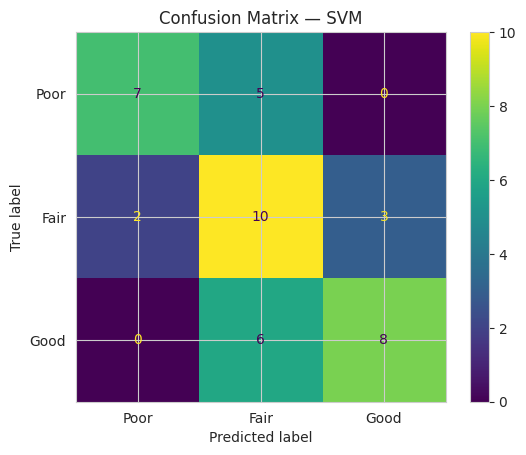

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, labels=["Poor", "Fair", "Good"])
plt.title(f"Confusion Matrix — {best_model_name}")
plt.show()

In [ ]:
import pandas as pd
from sklearn.ensemble import (
    GradientBoostingClassifier,
    RandomForestClassifier,
    VotingClassifier,
)
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer


numeric_features = ["Age", "Sleep_Duration_Hours", "Caffeine Cups", "Stress Level"]
nominal_features = ["Gender", "Sleep Time"]
ordinal_features = ["Screen Time Before Bed", "Caffeine Timing", "Exercise"]

ordinal_categories = [
    ["0–1 hours", "1–2 hours", "2–3 hours", "3+ hours"],                          # Screen Time Before Bed
    ["Never", "6+ hours before bed", "3–5 hours before bed", "0–2 hours before bed"],  # Caffeine Timing
    ["No Exercise", "Under 30 Minutes", "30-60 Minutes", "1-2 Hours", "2+"],       # Exercise
]

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

nominal_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

ordinal_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ordinal", OrdinalEncoder(categories=ordinal_categories, handle_unknown="use_encoded_value", unknown_value=-1)),
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_transformer, numeric_features),
    ("nominal", nominal_transformer, nominal_features),
    ("ordinal", ordinal_transformer, ordinal_features),
])



tuned_svc_soft = SVC(
    C=1,
    gamma=0.1,
    kernel="rbf",
    class_weight=None,
    probability=True,
    random_state=RANDOM_STATE,
)


tuned_svc_hard = SVC(
    C=1,
    gamma=0.1,
    kernel="rbf",
    class_weight=None,
    probability=False,
    random_state=RANDOM_STATE,
)



soft_models = [
    (
        "Logistic Regression",
        LogisticRegression(max_iter=2000, class_weight="balanced"),
    ),
    ("KNN", KNeighborsClassifier()),
    ("Tuned SVM", tuned_svc_soft),
    (
        "Decision Tree",
        DecisionTreeClassifier(
            random_state=RANDOM_STATE, class_weight="balanced"
        ),
    ),
    (
        "Random Forest",
        RandomForestClassifier(
            n_estimators=300,
            random_state=RANDOM_STATE,
            class_weight="balanced",
        ),
    ),
    (
        "Gradient Boosting",
        GradientBoostingClassifier(random_state=RANDOM_STATE),
    ),
]

hard_models = [
    (
        "Logistic Regression",
        LogisticRegression(max_iter=2000, class_weight="balanced"),
    ),
    ("KNN", KNeighborsClassifier()),
    ("Tuned SVM", tuned_svc_hard),
    (
        "Decision Tree",
        DecisionTreeClassifier(
            random_state=RANDOM_STATE, class_weight="balanced"
        ),
    ),
    (
        "Random Forest",
        RandomForestClassifier(
            n_estimators=300,
            random_state=RANDOM_STATE,
            class_weight="balanced",
        ),
    ),
    (
        "Gradient Boosting",
        GradientBoostingClassifier(random_state=RANDOM_STATE),
    ),
]



soft_ensemble_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        VotingClassifier(estimators=soft_models, voting="soft"),
    ),
])

hard_ensemble_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        VotingClassifier(estimators=hard_models, voting="hard"),
    ),
])



print("=== 1. Soft Voting Ensemble (with Tuned SVM) ===")
soft_ensemble_pipeline.fit(X_train, y_train)
y_pred_soft = soft_ensemble_pipeline.predict(X_test)

print(
    f"Soft Voting Test Macro F1-Score: {f1_score(y_test, y_pred_soft, average='macro'):.4f}\n"
)
print("Soft Voting Classification Report:")
print(classification_report(y_test, y_pred_soft))



print("\n" + "=" * 55)
print("=== 2. Hard Voting Ensemble (with Tuned SVM) ===")
hard_ensemble_pipeline.fit(X_train, y_train)
y_pred_hard = hard_ensemble_pipeline.predict(X_test)

print(
    f"Hard Voting Test Macro F1-Score: {f1_score(y_test, y_pred_hard, average='macro'):.4f}\n"
)
print("Hard Voting Classification Report:")
print(classification_report(y_test, y_pred_hard))

=== 1. Soft Voting Ensemble (with Tuned SVM) ===
Soft Voting Test Macro F1-Score: 0.6446

Soft Voting Classification Report:
              precision    recall  f1-score   support

        Fair       0.50      0.67      0.57        15
        Good       0.80      0.57      0.67        14
        Poor       0.73      0.67      0.70        12

    accuracy                           0.63        41
   macro avg       0.68      0.63      0.64        41
weighted avg       0.67      0.63      0.64        41


=== 2. Hard Voting Ensemble (with Tuned SVM) ===
Hard Voting Test Macro F1-Score: 0.6919

Hard Voting Classification Report:
              precision    recall  f1-score   support

        Fair       0.55      0.73      0.63        15
        Good       0.82      0.64      0.72        14
        Poor       0.80      0.67      0.73        12

    accuracy                           0.68        41
   macro avg       0.72      0.68      0.69        41
weighted avg       0.71      0.68      0.6

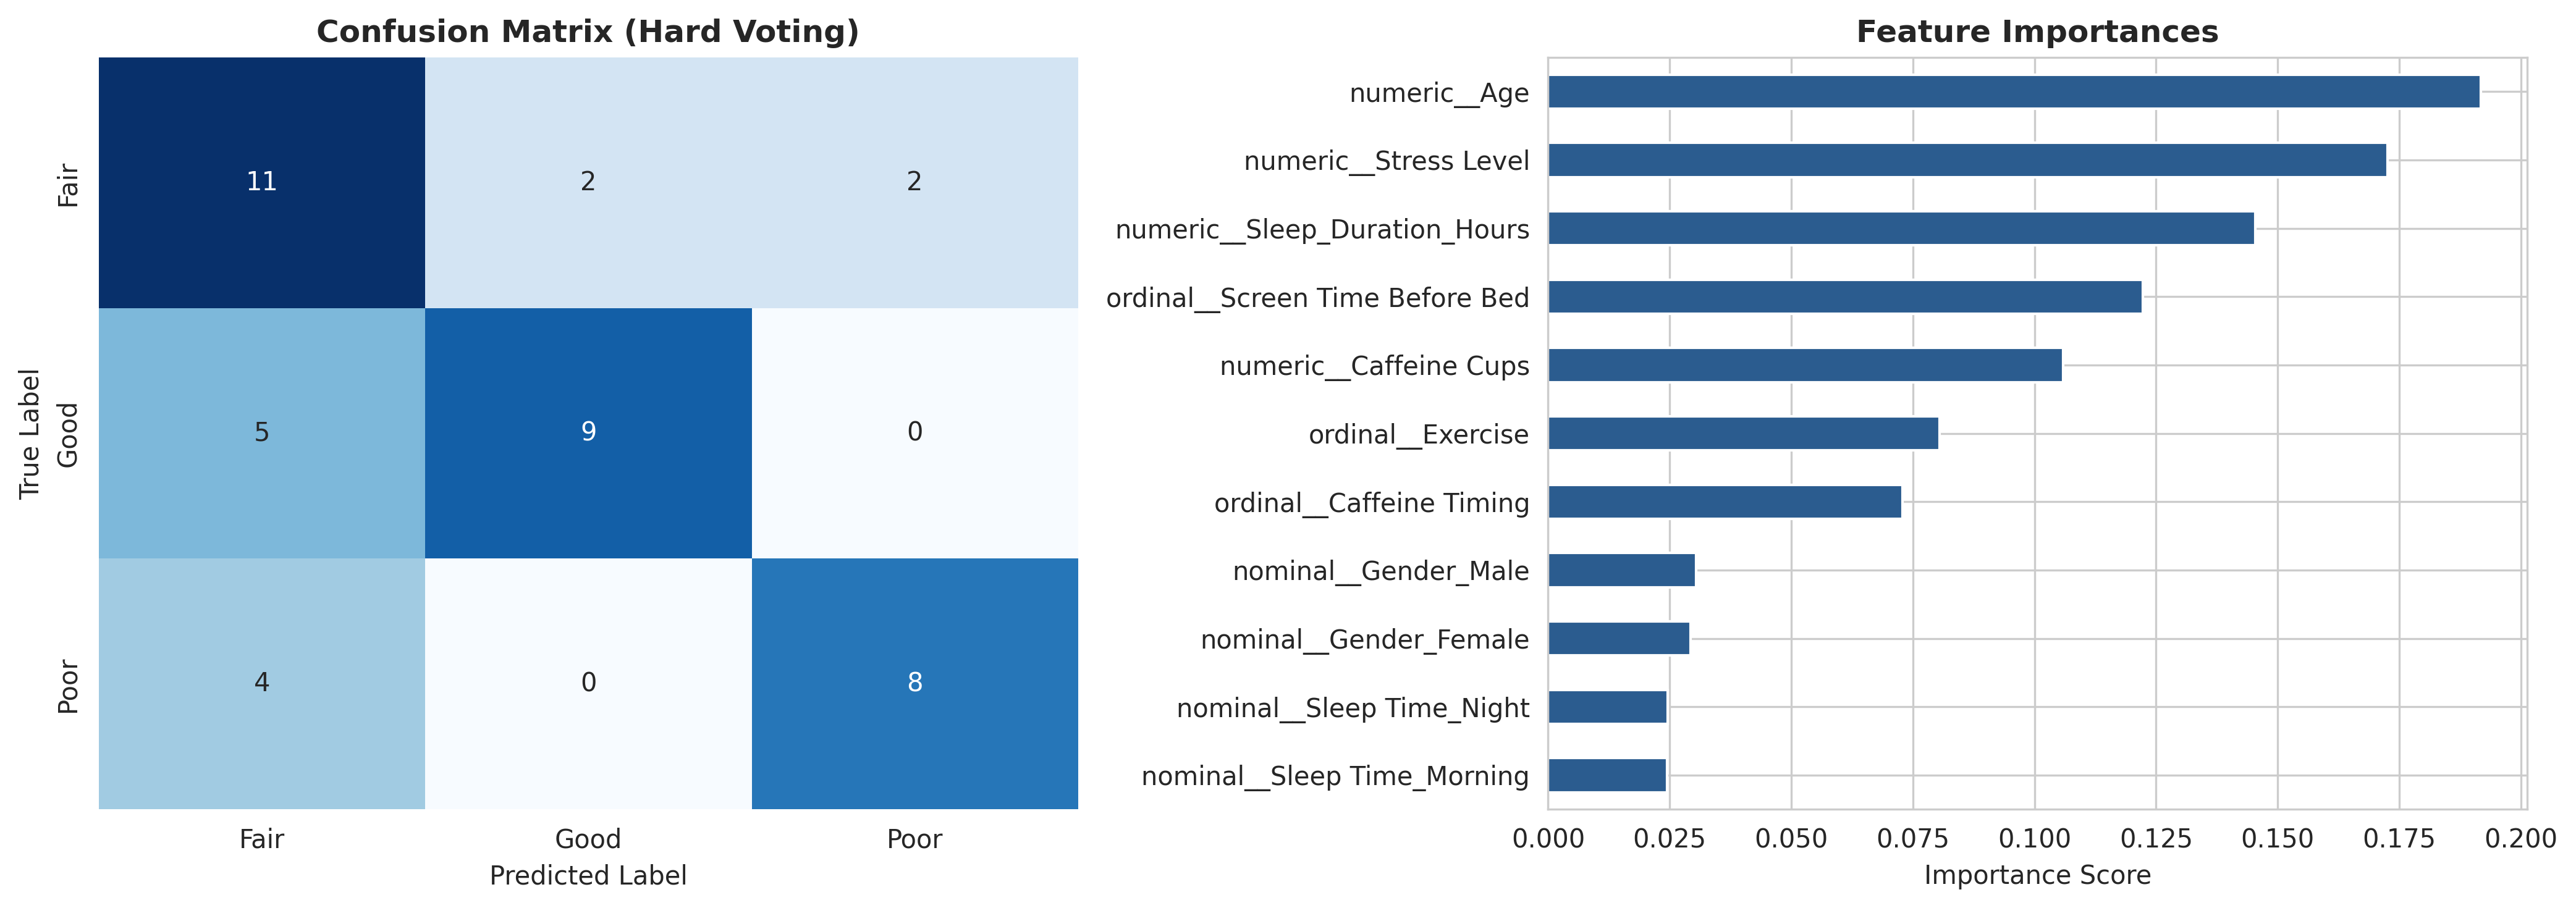

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=300)

# (Confusion Matrix)
cm = confusion_matrix(y_test, y_pred_hard)
class_names = ['Fair', 'Good', 'Poor']

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    ax=axes[0],
    cbar=False,
)
axes[0].set_title(
    'Confusion Matrix (Hard Voting)', fontsize=12, weight='bold'
)
axes[0].set_xlabel('Predicted Label', fontsize=10)
axes[0].set_ylabel('True Label', fontsize=10)

# Get the preprocessor from the hard ensemble pipeline
fitted_preprocessor = hard_ensemble_pipeline.named_steps['preprocessor']
# Get the feature names after preprocessing
transformed_feature_names = fitted_preprocessor.get_feature_names_out()

rf_model = hard_ensemble_pipeline.named_steps['model'].named_estimators_['Random Forest']

importances = pd.Series(
    rf_model.feature_importances_, index=transformed_feature_names
).sort_values(ascending=True)

importances.plot(kind='barh', ax=axes[1], color='#2b5c8f')
axes[1].set_title(
    'Feature Importances', fontsize=12, weight='bold'
)
axes[1].set_xlabel('Importance Score', fontsize=10)

plt.tight_layout()
plt.show()

## 11. Try It Out on One Person

This section tests the final trained pipeline on one made-up profile using the same prediction logic that the Streamlit app uses.

The app accepts `"Sleep Duration"` as a friendly category such as `"3–5 hours"`, while the trained model currently expects the engineered `"Sleep_Duration_Hours"` feature. The helper below performs that same conversion before prediction so the notebook and app stay aligned.


In [ ]:

def _prepare_user_profile(user_input):
    """Convert a friendly user profile into the model's feature format."""
    profile = dict(user_input)

    if "Sleep Duration" in profile and "Sleep_Duration_Hours" not in profile:
        profile["Sleep_Duration_Hours"] = SLEEP_DURATION_MAP.get(
            profile["Sleep Duration"]
        )
        profile.pop("Sleep Duration", None)

    # Keep only the exact features used during training.
    profile = {
        key: value
        for key, value in profile.items()
        if key in FEATURES
    }

    return profile


def predict_sleep_quality(user_input, pipeline=final_pipeline):
    """Predict Poor/Fair/Good sleep quality for one user profile."""
    prepared_profile = _prepare_user_profile(user_input)
    input_df = pd.DataFrame([prepared_profile])

    prediction = pipeline.predict(input_df)[0]
    probabilities = dict(
        zip(
            pipeline.classes_,
            pipeline.predict_proba(input_df)[0]
        )
    )

    return prediction, probabilities


example_profile = {
    "Age": 23,
    "Gender": "Female",
    "Sleep Duration": "3–5 hours",
    "Sleep Time": "Night",
    "Screen Time Before Bed": "3+ hours",
    "Caffeine Cups": 3,
    "Caffeine Timing": "0–2 hours before bed",
    "Exercise": "No Exercise",
    "Stress Level": 5,
}

prediction, probabilities = predict_sleep_quality(example_profile)

print("Predicted sleep quality:", prediction)
print("Probabilities:")

for label, p in probabilities.items():
    print(f"  {label}: {p:.1%}")


## 12. What-If Simulator Preview

The What-If Simulator compares the current profile with a modified scenario.

This is the same concept used by the Streamlit app: users can change one or more habits and see whether the model's predicted class or probability distribution changes.

This is a model-based simulation, not proof that a lifestyle change causes a particular sleep outcome.


In [ ]:

def compare_what_if(current_profile, changes, pipeline=final_pipeline):
    """Compare a current profile with a modified What-If scenario."""
    scenario_profile = {
        **current_profile,
        **changes
    }

    current_pred, current_probs = predict_sleep_quality(
        current_profile,
        pipeline
    )

    scenario_pred, scenario_probs = predict_sleep_quality(
        scenario_profile,
        pipeline
    )

    return {
        "current_prediction": current_pred,
        "scenario_prediction": scenario_pred,
        "current_probabilities": current_probs,
        "scenario_probabilities": scenario_probs,
    }


# What if this person lowered their stress,
# cut screen time, moved caffeine earlier,
# and added some exercise?
scenario = compare_what_if(
    example_profile,
    changes={
        "Stress Level": 2,
        "Screen Time Before Bed": "0–1 hours",
        "Caffeine Timing": "6+ hours before bed",
        "Exercise": "30-60 Minutes",
    },
)

print("Current prediction: ", scenario["current_prediction"])
print("Scenario prediction:", scenario["scenario_prediction"])

print("\nCurrent probabilities:")
for label, p in scenario["current_probabilities"].items():
    print(f"  {label}: {p:.1%}")

print("\nScenario probabilities:")
for label, p in scenario["scenario_probabilities"].items():
    print(f"  {label}: {p:.1%}")


## 13. Feature Importance for the App

The Streamlit app needs feature importance scores to explain which factors most influence the model's predictions.

Permutation importance is calculated on the held-out test set using Macro F1.


In [ ]:

perm = permutation_importance(
    final_pipeline,
    X_test,
    y_test,
    scoring="f1_macro",
    n_repeats=30,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance Mean": perm.importances_mean,
    "Importance Std": perm.importances_std,
}).sort_values(
    "Importance Mean",
    ascending=False
).reset_index(drop=True)

display(importance_df)


## 14. Save Everything Needed for the Streamlit App

The app uses six deployment artifacts:

1. `sleepwise_model.pkl` — trained preprocessing + model pipeline
2. `sleepwise_features.pkl` — feature names used by the model
3. `sleepwise_feature_importance.pkl` — permutation importance results
4. `sleepwise_metrics.pkl` — model selection and evaluation metrics
5. `sleepwise_clean_data.csv` — cleaned dataset for the Project Overview page
6. `sleepwise_model_comparison.csv` — model comparison table for the Project Overview page

The metadata below is generated directly from the notebook results so the app does not contain hard-coded accuracy values.


In [ ]:

train_pred = final_pipeline.predict(X_train)

train_accuracy = accuracy_score(
    y_train,
    train_pred
)

# Track whether the winning model was tuned.
was_tuned = (
    best_model_name in ["Random Forest", "SVM"]
    and "grid_search" in globals()
    and hasattr(grid_search, "best_estimator_")
    and final_pipeline is grid_search.best_estimator_
)

metrics = {
    "best_model_name": best_model_name,
    "model_class": type(final_pipeline.named_steps["model"]).__name__,
    "cv_macro_f1": float(best_cv_f1),
    "train_accuracy": float(train_accuracy),
    "test_accuracy": float(test_accuracy),
    "test_precision": float(test_precision),
    "test_recall": float(test_recall),
    "test_f1": float(test_f1),
    "models_compared": results_df["Model"].tolist(),
    "n_training_rows": int(len(X_train)),
    "n_test_rows": int(len(X_test)),
    "balancing_method": (
        "class_weight='balanced' for supported classifiers; "
        "no standalone SMOTE/SMOTENC step in the final CV pipeline"
    ),
    "age_range": (
        f"{int(df['Age'].min())}-{int(df['Age'].max())}"
        if "Age" in df.columns else "Not available"
    ),
    "was_tuned": bool(was_tuned),
}

joblib.dump(
    final_pipeline,
    "sleepwise_model.pkl"
)

joblib.dump(
    FEATURES,
    "sleepwise_features.pkl"
)

joblib.dump(
    importance_df,
    "sleepwise_feature_importance.pkl"
)

joblib.dump(
    metrics,
    "sleepwise_metrics.pkl"
)

# The app's Project Overview page can load these directly.
df.to_csv(
    "sleepwise_clean_data.csv",
    index=False
)

results_df.to_csv(
    "sleepwise_model_comparison.csv",
    index=False
)

print("Saved:")
print(" - sleepwise_model.pkl")
print(" - sleepwise_features.pkl")
print(" - sleepwise_feature_importance.pkl")
print(" - sleepwise_metrics.pkl")
print(" - sleepwise_clean_data.csv")
print(" - sleepwise_model_comparison.csv")


## 15. Summary

- Collected and cleaned the survey responses, removing duplicate records and invalid ages.
- Classified Sleep Quality Score into three classes: Poor, Fair, and Good.
- Kept the original sleep-duration category available to the user interface while converting it to the engineered feature used by the trained model.
- Used One-Hot Encoding for nominal categories and Ordinal Encoding for ordered categories inside the preprocessing pipeline.
- Compared six classifiers using 5-fold stratified cross-validation and Macro F1 as the main selection metric.
- Selected the strongest model based on cross-validated Macro F1 and evaluated it on an unseen test set using accuracy, macro precision, macro recall, macro F1, and a confusion matrix.
- Added a What-If Simulator preview that compares a current profile with changed habits.